In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"beyzahiz","key":"80dc9015b76a77a6a15c99f1d215774b"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nalisha/job-salary-prediction-dataset                              Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          10104        243                1  
rifatalam3/coffee-revenue-dataset                                  Coffee Revenue Dataset                                   38970  2026-04-07 05:32:05.120000            970         28                1  
sumeakash/impact-of-social-media-on-health                         Impact of Social Media on Health                         18598  2026-04-05 06:53:55.953000           2226         57     

In [5]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip brain-tumor-mri-dataset.zip

Görüntülenen çıkış son 5000 satıra kısaltıldı.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  inflatin

In [6]:
!ls

 brain-tumor-mri-dataset.zip   kaggle.json   Testing
'kaggle (1).json'	       sample_data   Training


In [7]:
!ls Training

glioma	meningioma  notumor  pituitary


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_dir = "Training"
test_dir = "Testing"

#CLAHE
#Görüntüdeki en parlak ve en koyu noktaları alıp tüm resme yayar. Ama bu bazen görüntüyü çok gürültülü (parazitli) yapar.
#Görüntünün karanlık ve aydınlık bölgelerini dengeleyerek detayları ortaya çıkaran bir teknik.
#

def medical_preprocessing(img):
    img = img.astype('uint8') #Görseli uint8 formatına al. CLAHE sadece 0-255 arası tamsayılarla çalışır
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)) # CLAHE Uygula
    # clipLimit=2.0: Kontrastı ne kadar sınırlayacağı (2.0 genelde iyidir)
    # tileGridSize=(8,8): Görüntüyü 8x8'lik küçük parçalara böler
    for i in range(3): # Renkli kanallara ayrı ayrı uygula
        img[:,:,i] = clahe.apply(img[:,:,i])
    return img.astype('float32') # Model float bekler

train_datagen = ImageDataGenerator(
    preprocessing_function=medical_preprocessing, # Rescale SİLİNDİ, bu EKLENDİ
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(preprocessing_function=medical_preprocessing)

train_generator = train_datagen.flow_from_directory( #bu fonksiyon klasörleri okur, görselleri yükler, label üretir
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [9]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [10]:
#EfficentNet Modeli

import cv2
from tensorflow.keras import layers,models
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False, #sınıflandırma katmanları modelin dışında bırakılır yani model özellik çıkarıcı olarak kullanılır.
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

# SADECE ÜST KATMANLARI EĞİT
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Sadece üst katmanlar eğitiliyor...")
model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator
)

# FİNE-TUNİNG
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau( #model gelişmekte zorlandığında öğrenme hızını %80 oranında azaltarak daha hassas öğrenmesini sağlıyor
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

#Fine-tuning yaparken çok düşük bir learning rate (1e-5) seçilir
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Fine-tuning aşamasına geçiliyor...")
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=test_generator,
    callbacks=[early_stop, reduce_lr]
)



Sadece üst katmanlar eğitiliyor...
Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 126s 545ms/step - accuracy: 0.7727 - loss: 0.5828 - val_accuracy: 0.7763 - val_loss: 0.5587
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 486ms/step - accuracy: 0.8529 - loss: 0.3912 - val_accuracy: 0.8350 - val_loss: 0.4546
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 86s 490ms/step - accuracy: 0.8720 - loss: 0.3426 - val_accuracy: 0.8456 - val_loss: 0.4471
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 494ms/step - accuracy: 0.8871 - loss: 0.3068 - val_accuracy: 0.8475 - val_loss: 0.4492
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 89s 510ms/step - accuracy: 0.8968 - loss: 0.2843 - val_accuracy: 0.8531 - val_loss: 0.4594
Fine-tuning aşamasına geçiliyor...
Epoch 1/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 121s 531ms/step - accuracy: 0.8279 - loss: 0.4613 - val_accuracy: 0.8394 - val_loss: 0.4383 - learning_rate: 1.0000e-05
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 86s 491ms/step - accuracy: 0.8691 - loss: 0.3456 - val_accuracy: 0.8425 - val_l

In [11]:
model.save("mri_model.keras")

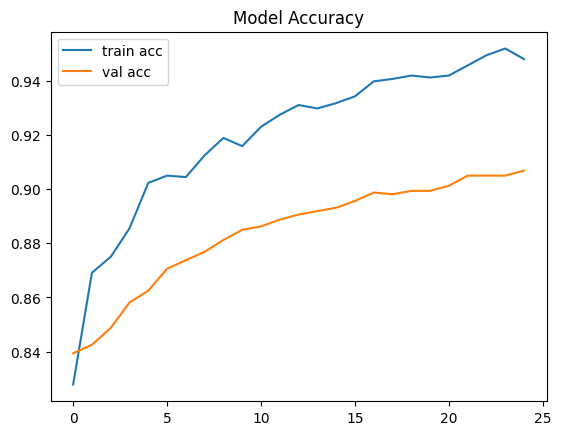

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [18]:
#Grad-CAM

import cv2

def load_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = medical_preprocessing(img) # Eğitimle aynı ön işleme.
#medical_preprocessing (CLAHE) ekledik ki model test ederken de görüntüleri netleştirilmiş olarak görsün. Eğer test resmi ile eğitim resmi farklı işlenirse Grad-CAM saçmalar.
#Eğer modelinizi eğitirken görüntülere CLAHE uyguladıysanız, test sırasında da AYNI CLAHE işlemini uygulamanız şarttır. Aksi takdirde model kafayı yer.
    return np.expand_dims(img, axis=0)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # 1. İç katmanı bulma (Aynı mantık)
    try:
        last_conv_layer = model.get_layer(last_conv_layer_name)
    except ValueError:
        base_model = model.layers[0]
        last_conv_layer = base_model.get_layer(last_conv_layer_name)
        model = base_model

    # 2. Grad-model oluşturma
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[last_conv_layer.output, model.output]
    )

    # 3. Gradyan hesaplama
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        # Tahminlerin en yüksek olduğu sınıfın indeksini bul
        class_idx = tf.argmax(predictions[0])
        # Sadece o sınıfa ait olasılık değerini al (Loss)
        # BURASI DEĞİŞTİ: Boyut uyuşmazlığını önlemek için tf.gather kullanıyoruz
        loss = tf.gather(predictions[0], class_idx)

    # 4. Gradyanları alma
    grads = tape.gradient(loss, conv_outputs)

    # 5. Ağırlıklı ortalama ve Isı haritası oluşturma
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Normalize etme
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

#görselleştirme
def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    #normalize + uint8 garanti
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / np.max(heatmap)
    heatmap = np.uint8(255 * heatmap)

    #resize
    heatmap = cv2.resize(heatmap, (224, 224))

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

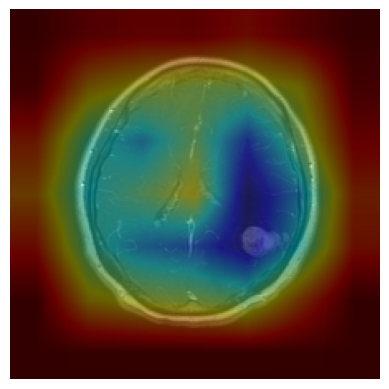

In [20]:
# Test
img = load_image(img_path)

# Fonksiyon artık Sequential olduğunu kendisi anlayacaktır
heatmap = make_gradcam_heatmap(
    img,
    model, # Direkt ana modeli gönder
    last_conv_layer_name="top_conv"
)

display_gradcam(img_path, heatmap)